In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [4]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train Logistic Regression

In [5]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8038379530916845
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Train Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.757640369580668
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



### Save best model

In [7]:
joblib.dump(rf_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/model_features.pkl")


['../models/model_features.pkl']

### Add confusion matrix

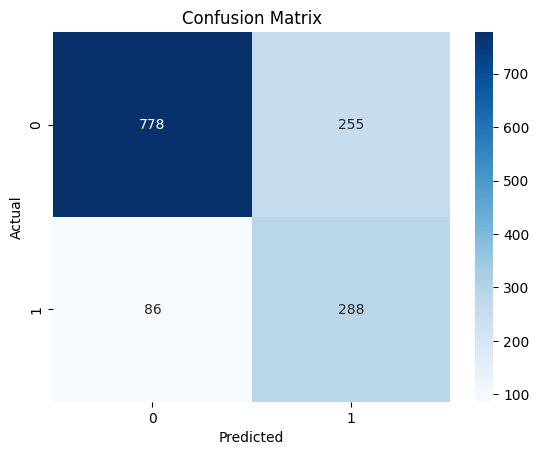

In [10]:
import seaborn as sns

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

While the model achieves ~79% accuracy, recall for churned customers is lower (~50%), indicating that many churn cases are missed. This highlights the importance of optimizing for recall in business scenarios where customer retention is critical.

Optimized Random Forest model to improve churn recall using class balancing and hyperparameter tuning, prioritizing business impact over raw accuracy.